# 05 — Molecular Subtype Analysis

## Objective

This notebook investigates the molecular subtypes of TCGA breast cancer (TCGA-BRCA) and examines how these subtypes differ in clinical characteristics.

### Main goals

1. Obtain molecular subtype information for TCGA-BRCA patients.
2. Explore the distribution of breast cancer molecular subtypes.
3. Integrate molecular subtype data with the cleaned clinical cohort.
4. Compare clinical characteristics across molecular subtypes.
5. Prepare the integrated dataset for downstream gene expression analysis.

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# Define project paths
PROJECT_DIR = Path("..")
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

# Load cleaned TCGA-BRCA clinical dataset
clinical_df = pd.read_csv(RESULTS_DIR / "TCGA_BRCA_clinical_data.csv")

print("Clinical dataset shape:", clinical_df.shape)
print("\nColumns:")
print(clinical_df.columns.tolist())

clinical_df.head()

Clinical dataset shape: (1098, 8)

Columns:
['patient_id', 'sex', 'vital_status', 'age_at_index', 'age_at_diagnosis_days', 'pathologic_stage', 'days_to_death', 'days_to_last_follow_up']


,patient_id,sex,vital_status,age_at_index,age_at_diagnosis_days,pathologic_stage,days_to_death,days_to_last_follow_up
0,TCGA-BH-A0B2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TCGA-A8-A08S,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TCGA-A8-A09C,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TCGA-BH-A1F5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TCGA-A2-A0YT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
from pathlib import Path
import pandas as pd

print("=== CSV files in results ===")
for file in RESULTS_DIR.glob("*.csv"):
    print(file.name)

print("\n=== Files in data ===")
DATA_DIR = PROJECT_DIR / "data"

for file in DATA_DIR.iterdir():
    print(file.name)

=== CSV files in results ===
stage_pairwise_logrank_results.csv
TCGA_BRCA_clinical_data.csv
stage_global_logrank_result.csv
clinical_cohort_summary.csv

=== Files in data ===
clinical.project-tcga-brca.2026-08-13.tar.gz
.DS_Store
.gitkeep
clinical.project-tcga-brca.2026-08-13
brca_tcga_pan_can_atlas_2018
processed


In [4]:
print("=== Files in data/processed ===")

PROCESSED_DIR = DATA_DIR / "processed"

for file in PROCESSED_DIR.rglob("*"):
    if file.is_file():
        print(file.relative_to(PROCESSED_DIR))

=== Files in data/processed ===
tcga_brca_clinical_clean.csv


In [5]:
clean_clinical_df = pd.read_csv(
    PROCESSED_DIR / "tcga_brca_clinical_clean.csv"
)

print("Clean clinical dataset shape:", clean_clinical_df.shape)

print("\nColumns:")
print(clean_clinical_df.columns.tolist())

print("\nMissing values:")
print(clean_clinical_df.isna().sum())

print("\nFirst 5 rows:")
display(clean_clinical_df.head())

Clean clinical dataset shape: (1098, 17)

Columns:
['case_id', 'patient_id', 'sex', 'race', 'ethnicity', 'age_at_diagnosis_days', 'age_at_diagnosis_years', 'primary_diagnosis', 'stage', 'pathologic_T', 'pathologic_N', 'pathologic_M', 'vital_status', 'days_to_death', 'latest_follow_up_days', 'overall_survival_days', 'overall_survival_event']

Missing values:
case_id                     0
patient_id                  0
sex                         1
race                       96
ethnicity                 167
age_at_diagnosis_days      16
age_at_diagnosis_years     16
primary_diagnosis           1
stage                      12
pathologic_T                1
pathologic_N                1
pathologic_M                1
vital_status                1
days_to_death             947
latest_follow_up_days       3
overall_survival_days       4
overall_survival_event      1
dtype: int64

First 5 rows:


,case_id,patient_id,sex,race,ethnicity,age_at_diagnosis_days,age_at_diagnosis_years,primary_diagnosis,stage,pathologic_T,pathologic_N,pathologic_M,vital_status,days_to_death,latest_follow_up_days,overall_survival_days,overall_survival_event
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,TCGA-E2-A1IU,female,white,not hispanic or latino,22279.0,60.996578,"Infiltrating duct carcinoma, NOS",Stage IA,T1c,N0 (mol+),M0,Alive,NaN,337.0,337.0,0.0
1,0045349c-69d9-4306-a403-c9c1fa836644,TCGA-A1-A0SB,female,white,not hispanic or latino,25833.0,70.726899,Adenoid cystic carcinoma,Stage I,T1c,N0,M0,Alive,NaN,259.0,259.0,0.0
2,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,TCGA-A2-A04W,female,white,not hispanic or latino,18345.0,50.225873,Apocrine adenocarcinoma,Stage IIB,T2,N1mi,M0,Alive,NaN,3102.0,3102.0,0.0
3,00a2d166-78c9-4687-a195-3d6315c27574,TCGA-AN-A0AM,female,white,not hispanic or latino,20713.0,56.709103,"Infiltrating duct carcinoma, NOS",Stage IIA,T2,N0,M0,Alive,NaN,5.0,5.0,0.0
4,00b11ca8-8540-4a3d-b602-ec754b00230b,TCGA-LL-A440,female,white,not hispanic or latino,22497.0,61.593429,"Lobular carcinoma, NOS",Stage IA,T1c,N0 (i-),MX,Alive,NaN,759.0,759.0,0.0


In [6]:
# Search for subtype- or receptor-related columns
keywords = [
    "subtype",
    "pam50",
    "er",
    "pr",
    "her2",
    "estrogen",
    "progesterone"
]

matching_columns = [
    col for col in clean_clinical_df.columns
    if any(keyword in col.lower() for keyword in keywords)
]

print("Potential molecular subtype / receptor columns:")
print(matching_columns)

Potential molecular subtype / receptor columns:
['primary_diagnosis', 'overall_survival_days', 'overall_survival_event']


In [7]:
# More specific search for breast cancer subtype / receptor columns

specific_keywords = [
    "pam50",
    "subtype",
    "estrogen",
    "progesterone",
    "her2",
    "er_status",
    "pr_status",
    "er_status_by_ihc",
    "pr_status_by_ihc",
    "her2_status"
]

matching_columns = [
    col for col in clean_clinical_df.columns
    if any(keyword in col.lower() for keyword in specific_keywords)
]

print("Specific molecular subtype / receptor columns:")
print(matching_columns)

Specific molecular subtype / receptor columns:
[]


In [8]:
import requests

url = "https://pancanatlas.xenahubs.net"

try:
    response = requests.get(url, timeout=10)
    print("Status code:", response.status_code)
    print("Connection successful!")
except Exception as e:
    print("Connection failed:")
    print(e)

Status code: 200
Connection successful!


## 2. Retrieve PAM50 Molecular Subtype Data

In [9]:
import requests

clinical_url = (
    "https://tcga.xenahubs.net/download/"
    "tcga.brca.samplemap%2Fbrca_clinicalmatrix"
)

response = requests.get(clinical_url, timeout=30)

print("Status code:", response.status_code)
print("Downloaded bytes:", len(response.content))
print(response.text[:500])

Status code: 403
Downloaded bytes: 275
<?xml version="1.0" encoding="UTF-8"?>
<Error><Code>AccessDenied</Code><Message>Access Denied</Message><RequestId>ZT507XTZKJSJJ8H0</RequestId><HostId>Jraibm2T47SvPOO35bujyP/bST/i8/gpU7o+RAhZnd/EBWFIUWS9PEessaJuh4IHAXLkuOdtqNMyWQoMM7io/YE2ug+da6LsTSYigmWhMuo=</HostId></Error>


In [10]:
from pathlib import Path

CBIO_DIR = DATA_DIR / "brca_tcga_pan_can_atlas_2018"

search_terms = [
    "PAM50",
    "SUBTYPE",
    "ER_STATUS",
    "PR_STATUS",
    "HER2_STATUS",
    "CLAUDIN"
]

for filename in [
    "data_clinical_patient.txt",
    "data_clinical_sample.txt"
]:
    file_path = CBIO_DIR / filename
    
    print(f"\n=== {filename} ===")
    
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    
    for line in lines[:20]:
        if any(term.lower() in line.lower() for term in search_terms):
            print(line.strip())


=== data_clinical_patient.txt ===
#Patient Identifier	Subtype	TCGA PanCanAtlas Cancer Type Acronym	Other Patient ID	Diagnosis Age	Sex	Neoplasm Disease Stage American Joint Committee on Cancer Code	American Joint Committee on Cancer Publication Version Type	Last Communication Contact from Initial Pathologic Diagnosis Date	Birth from Initial Pathologic Diagnosis Date	Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value	Ethnicity Category	Form completion date	Neoadjuvant Therapy Type Administered Prior To Resection Text	ICD-10 Classification	International Classification of Diseases for Oncology, Third Edition ICD-O-3 Histology Code	International Classification of Diseases for Oncology, Third Edition ICD-O-3 Site Code	Informed consent verified	New Neoplasm Event Post Initial Therapy Indicator	American Joint Committee on Cancer Metastasis Stage Code	Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code	American Joint Committee on Cancer Tumor Stage Cod

In [11]:
clinical_patient_cbio = pd.read_csv(
    CBIO_DIR / "data_clinical_patient.txt",
    sep="\t",
    comment="#"
)

clinical_sample_cbio = pd.read_csv(
    CBIO_DIR / "data_clinical_sample.txt",
    sep="\t",
    comment="#"
)

print("Patient clinical shape:", clinical_patient_cbio.shape)
print("\nPatient columns:")
print(clinical_patient_cbio.columns.tolist())

print("\nSample clinical shape:", clinical_sample_cbio.shape)
print("\nSample columns:")
print(clinical_sample_cbio.columns.tolist())

Patient clinical shape: (1084, 38)

Patient columns:
['PATIENT_ID', 'SUBTYPE', 'CANCER_TYPE_ACRONYM', 'OTHER_PATIENT_ID', 'AGE', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'AJCC_STAGING_EDITION', 'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'ETHNICITY', 'FORM_COMPLETION_DATE', 'HISTORY_NEOADJUVANT_TRTYN', 'ICD_10', 'ICD_O_3_HISTOLOGY', 'ICD_O_3_SITE', 'INFORMED_CONSENT_VERIFIED', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PERSON_NEOPLASM_CANCER_STATUS', 'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT', 'PRIOR_DX', 'RACE', 'RADIATION_THERAPY', 'WEIGHT', 'IN_PANCANPATHWAYS_FREEZE', 'OS_STATUS', 'OS_MONTHS', 'DSS_STATUS', 'DSS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS', 'PFS_STATUS', 'PFS_MONTHS', 'GENETIC_ANCESTRY_LABEL']

Sample clinical shape: (1084, 19)

Sample columns:
['PATIENT_ID', 'SAMPLE_ID', 'ONCOTREE_CODE', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'TUMOR_TYPE', 'GRADE', 'TISSUE_PROSPECTIVE_COLLECTION_INDICATOR', '

In [12]:
print("SUBTYPE value counts:")
print(
    clinical_patient_cbio["SUBTYPE"]
    .value_counts(dropna=False)
)

print("\nFirst 10 patients:")
display(
    clinical_patient_cbio[
        ["PATIENT_ID", "SUBTYPE"]
    ].head(10)
)

SUBTYPE value counts:
SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
NaN            103
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64

First 10 patients:


,PATIENT_ID,SUBTYPE
0,TCGA-3C-AAAU,BRCA_LumA
1,TCGA-3C-AALI,BRCA_Her2
2,TCGA-3C-AALJ,BRCA_LumB
3,TCGA-3C-AALK,BRCA_LumA
4,TCGA-4H-AAAK,BRCA_LumA
5,TCGA-5L-AAT0,BRCA_LumA
6,TCGA-5T-A9QA,BRCA_LumB
7,TCGA-A1-A0SB,BRCA_Normal
8,TCGA-A1-A0SD,BRCA_LumA
9,TCGA-A1-A0SE,BRCA_LumA


In [13]:
# Create a clean PAM50 subtype table

pam50_df = clinical_patient_cbio[
    ["PATIENT_ID", "SUBTYPE"]
].copy()

# Rename columns for consistency with our GDC clinical dataset
pam50_df = pam50_df.rename(
    columns={
        "PATIENT_ID": "patient_id",
        "SUBTYPE": "pam50_subtype"
    }
)

# Clean subtype labels
subtype_map = {
    "BRCA_LumA": "Luminal A",
    "BRCA_LumB": "Luminal B",
    "BRCA_Basal": "Basal-like",
    "BRCA_Her2": "HER2-enriched",
    "BRCA_Normal": "Normal-like"
}

pam50_df["pam50_subtype"] = pam50_df["pam50_subtype"].replace(subtype_map)

print("PAM50 dataset shape:", pam50_df.shape)

print("\nCleaned PAM50 subtype distribution:")
print(pam50_df["pam50_subtype"].value_counts(dropna=False))

display(pam50_df.head())

PAM50 dataset shape: (1084, 2)

Cleaned PAM50 subtype distribution:
pam50_subtype
Luminal A        499
Luminal B        197
Basal-like       171
NaN              103
HER2-enriched     78
Normal-like       36
Name: count, dtype: int64


,patient_id,pam50_subtype
0,TCGA-3C-AAAU,Luminal A
1,TCGA-3C-AALI,HER2-enriched
2,TCGA-3C-AALJ,Luminal B
3,TCGA-3C-AALK,Luminal A
4,TCGA-4H-AAAK,Luminal A


In [14]:
# Merge PAM50 subtype information with cleaned clinical data

clinical_subtype_df = clean_clinical_df.merge(
    pam50_df,
    on="patient_id",
    how="left"
)

print("Original clinical patients:", clean_clinical_df.shape[0])
print("Merged dataset patients:", clinical_subtype_df.shape[0])

print(
    "Patients with PAM50 subtype:",
    clinical_subtype_df["pam50_subtype"].notna().sum()
)

print(
    "Patients without PAM50 subtype:",
    clinical_subtype_df["pam50_subtype"].isna().sum()
)

print("\nPAM50 distribution after merge:")
print(clinical_subtype_df["pam50_subtype"].value_counts(dropna=False))

Original clinical patients: 1098
Merged dataset patients: 1098
Patients with PAM50 subtype: 981
Patients without PAM50 subtype: 117

PAM50 distribution after merge:
pam50_subtype
Luminal A        499
Luminal B        197
Basal-like       171
NaN              117
HER2-enriched     78
Normal-like       36
Name: count, dtype: int64


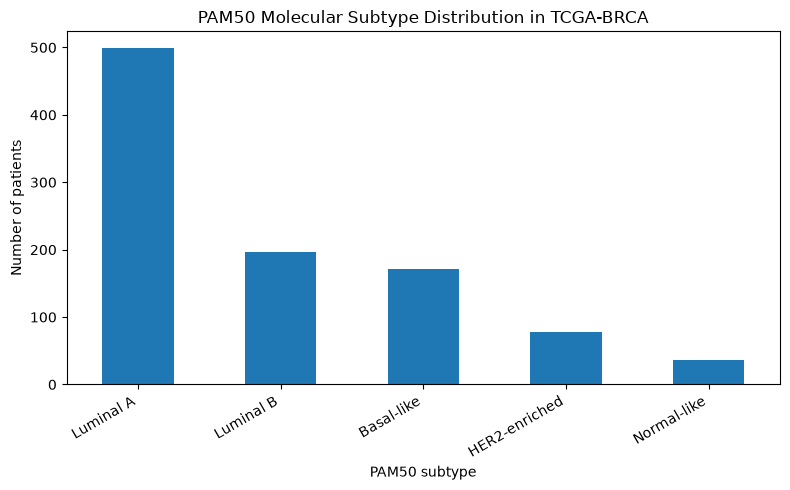

In [15]:
import matplotlib.pyplot as plt

subtype_order = [
    "Luminal A",
    "Luminal B",
    "Basal-like",
    "HER2-enriched",
    "Normal-like"
]

subtype_counts = (
    clinical_subtype_df["pam50_subtype"]
    .value_counts()
    .reindex(subtype_order)
)

plt.figure(figsize=(8, 5))

subtype_counts.plot(kind="bar")

plt.title("PAM50 Molecular Subtype Distribution in TCGA-BRCA")
plt.xlabel("PAM50 subtype")
plt.ylabel("Number of patients")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "pam50_subtype_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
print("=== PAM50 SUBTYPE QC ===")
print("Total clinical patients:", len(clinical_subtype_df))
print(
    "Patients with PAM50 subtype:",
    clinical_subtype_df["pam50_subtype"].notna().sum()
)
print(
    "Patients without PAM50 subtype:",
    clinical_subtype_df["pam50_subtype"].isna().sum()
)

print("\nSubtype distribution:")
print(subtype_counts)

print(
    "\nPercentage with PAM50 annotation:",
    round(
        clinical_subtype_df["pam50_subtype"].notna().mean() * 100,
        1
    ),
    "%"
)

=== PAM50 SUBTYPE QC ===
Total clinical patients: 1098
Patients with PAM50 subtype: 981
Patients without PAM50 subtype: 117

Subtype distribution:
pam50_subtype
Luminal A        499
Luminal B        197
Basal-like       171
HER2-enriched     78
Normal-like       36
Name: count, dtype: int64

Percentage with PAM50 annotation: 89.3 %


In [17]:
## 3. Clinical Characteristics Across PAM50 Subtypes

In [18]:
# Compare age at diagnosis across PAM50 subtypes

age_summary = (
    clinical_subtype_df
    .dropna(subset=["pam50_subtype", "age_at_diagnosis_years"])
    .groupby("pam50_subtype")["age_at_diagnosis_years"]
    .agg(["count", "mean", "median", "std"])
    .reindex(subtype_order)
)

print("Age at diagnosis by PAM50 subtype:")
display(age_summary.round(2))

Age at diagnosis by PAM50 subtype:


,count,mean,median,std
pam50_subtype,,,,
Luminal A,490,60.01,61.08,13.46
Luminal B,195,59.35,58.90,13.01
Basal-like,171,56.03,54.06,12.47
HER2-enriched,75,59.13,57.60,13.09
Normal-like,36,55.48,54.20,12.09


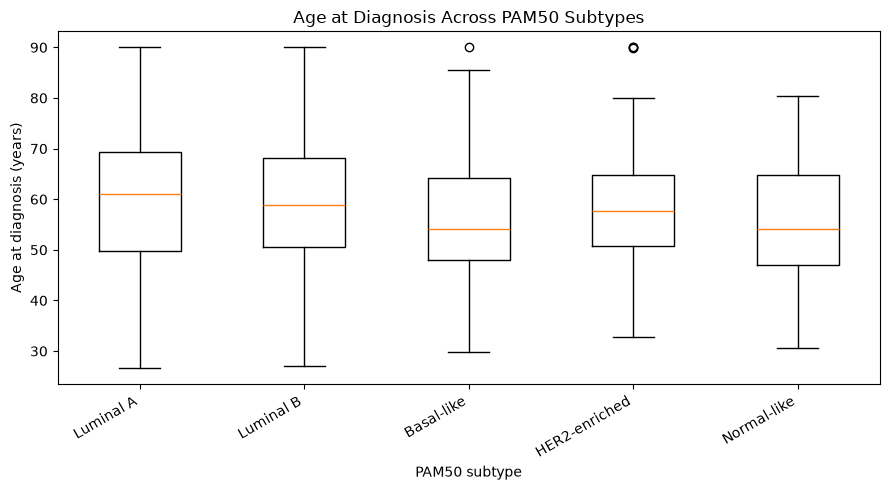

In [19]:
age_plot_df = clinical_subtype_df.dropna(
    subset=["pam50_subtype", "age_at_diagnosis_years"]
)

plt.figure(figsize=(9, 5))

age_data = [
    age_plot_df.loc[
        age_plot_df["pam50_subtype"] == subtype,
        "age_at_diagnosis_years"
    ]
    for subtype in subtype_order
]

plt.boxplot(
    age_data,
    tick_labels=subtype_order
)

plt.title("Age at Diagnosis Across PAM50 Subtypes")
plt.xlabel("PAM50 subtype")
plt.ylabel("Age at diagnosis (years)")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "age_by_pam50_subtype.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
from scipy.stats import kruskal

age_groups = [
    age_plot_df.loc[
        age_plot_df["pam50_subtype"] == subtype,
        "age_at_diagnosis_years"
    ]
    for subtype in subtype_order
]

kruskal_stat, kruskal_p = kruskal(*age_groups)

print("=== Kruskal-Wallis Test: Age Across PAM50 Subtypes ===")
print(f"H statistic: {kruskal_stat:.3f}")
print(f"p-value: {kruskal_p:.6g}")

=== Kruskal-Wallis Test: Age Across PAM50 Subtypes ===
H statistic: 15.249
p-value: 0.00421136


In [21]:
from scipy.stats import mannwhitneyu
from itertools import combinations
import pandas as pd

pairwise_results = []

for subtype1, subtype2 in combinations(subtype_order, 2):
    
    group1 = age_plot_df.loc[
        age_plot_df["pam50_subtype"] == subtype1,
        "age_at_diagnosis_years"
    ]
    
    group2 = age_plot_df.loc[
        age_plot_df["pam50_subtype"] == subtype2,
        "age_at_diagnosis_years"
    ]
    
    stat, p = mannwhitneyu(
        group1,
        group2,
        alternative="two-sided"
    )
    
    pairwise_results.append({
        "subtype_1": subtype1,
        "subtype_2": subtype2,
        "U_statistic": stat,
        "p_value": p
    })

age_pairwise_df = pd.DataFrame(pairwise_results)

# Bonferroni correction
n_tests = len(age_pairwise_df)

age_pairwise_df["p_adjusted"] = (
    age_pairwise_df["p_value"] * n_tests
).clip(upper=1)

age_pairwise_df["significant"] = (
    age_pairwise_df["p_adjusted"] < 0.05
)

display(
    age_pairwise_df.sort_values("p_adjusted")
)

,subtype_1,subtype_2,U_statistic,p_value,p_adjusted,significant
1,Luminal A,Basal-like,49444.0,0.000446,0.004465,True
4,Luminal B,Basal-like,19336.0,0.008364,0.083638,False
3,Luminal A,Normal-like,10497.5,0.056738,0.567377,False
7,Basal-like,HER2-enriched,5538.0,0.088927,0.889274,False
0,Luminal A,Luminal B,49268.0,0.523084,1.000000,False
2,Luminal A,HER2-enriched,19425.5,0.425147,1.000000,False
5,Luminal B,HER2-enriched,7554.5,0.674326,1.000000,False
6,Luminal B,Normal-like,4094.5,0.112915,1.000000,False
8,Basal-like,Normal-like,3086.0,0.981682,1.000000,False
9,HER2-enriched,Normal-like,1538.0,0.237546,1.000000,False


## 4. Pathological Stage Across PAM50 Subtypes

In [22]:
print("Stage values:")
print(
    clinical_subtype_df["stage"]
    .value_counts(dropna=False)
)

Stage values:
stage
Stage IIA     358
Stage IIB     257
Stage IIIA    155
Stage I        90
Stage IA       86
Stage IIIC     65
Stage IIIB     27
Stage IV       20
Stage X        13
NaN            12
Stage IB        7
Stage II        6
Stage III       2
Name: count, dtype: int64


In [23]:
# Group detailed pathological stages into Stage I-IV

def group_stage(stage):
    if pd.isna(stage):
        return np.nan

    stage = str(stage).strip()

    if stage in ["Stage I", "Stage IA", "Stage IB"]:
        return "Stage I"

    elif stage in ["Stage II", "Stage IIA", "Stage IIB"]:
        return "Stage II"

    elif stage in ["Stage III", "Stage IIIA", "Stage IIIB", "Stage IIIC"]:
        return "Stage III"

    elif stage == "Stage IV":
        return "Stage IV"

    else:
        return np.nan


clinical_subtype_df["stage_group"] = (
    clinical_subtype_df["stage"].apply(group_stage)
)

print("Grouped stage distribution:")
print(
    clinical_subtype_df["stage_group"]
    .value_counts(dropna=False)
)

print(
    "\nPatients usable for stage analysis:",
    clinical_subtype_df["stage_group"].notna().sum()
)

Grouped stage distribution:
stage_group
Stage II     621
Stage III    249
Stage I      183
NaN           25
Stage IV      20
Name: count, dtype: int64

Patients usable for stage analysis: 1073


In [24]:
stage_subtype_table = pd.crosstab(
    clinical_subtype_df["pam50_subtype"],
    clinical_subtype_df["stage_group"]
)

stage_subtype_table = stage_subtype_table.reindex(
    index=subtype_order,
    columns=["Stage I", "Stage II", "Stage III", "Stage IV"]
)

print("PAM50 subtype × pathological stage:")
display(stage_subtype_table)

PAM50 subtype × pathological stage:


stage_group,Stage I,Stage II,Stage III,Stage IV
pam50_subtype,,,,
Luminal A,108,264,106,7
Luminal B,23,109,58,4
Basal-like,22,122,21,2
HER2-enriched,7,47,19,3
Normal-like,6,20,9,1


In [25]:
stage_subtype_percent = (
    stage_subtype_table
    .div(stage_subtype_table.sum(axis=1), axis=0)
    * 100
)

print("Stage distribution within each PAM50 subtype (%):")
display(stage_subtype_percent.round(1))

Stage distribution within each PAM50 subtype (%):


stage_group,Stage I,Stage II,Stage III,Stage IV
pam50_subtype,,,,
Luminal A,22.3,54.4,21.9,1.4
Luminal B,11.9,56.2,29.9,2.1
Basal-like,13.2,73.1,12.6,1.2
HER2-enriched,9.2,61.8,25.0,3.9
Normal-like,16.7,55.6,25.0,2.8


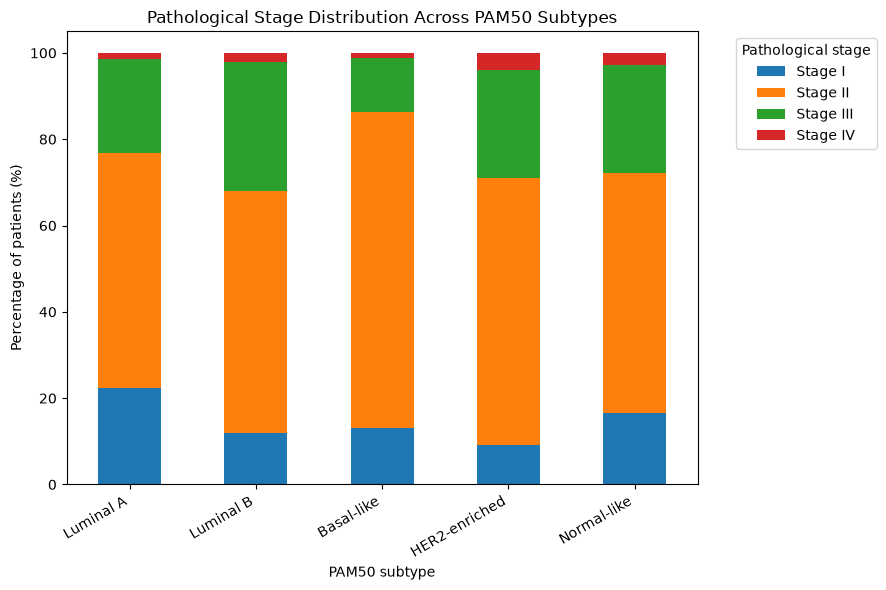

In [26]:
ax = stage_subtype_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("Pathological Stage Distribution Across PAM50 Subtypes")
plt.xlabel("PAM50 subtype")
plt.ylabel("Percentage of patients (%)")
plt.xticks(rotation=30, ha="right")

plt.legend(
    title="Pathological stage",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "stage_distribution_by_pam50_subtype.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(
    stage_subtype_table
)

print("=== Chi-square Test: PAM50 Subtype vs Pathological Stage ===")
print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.6g}")

=== Chi-square Test: PAM50 Subtype vs Pathological Stage ===
Chi-square statistic: 37.991
Degrees of freedom: 12
p-value: 0.000154057


In [28]:
expected_df = pd.DataFrame(
    expected,
    index=stage_subtype_table.index,
    columns=stage_subtype_table.columns
)

print("Expected counts:")
display(expected_df.round(2))

print("Number of expected cells < 5:")
print((expected_df < 5).sum().sum())

print("\nMinimum expected count:")
print(expected_df.min().min())

Expected counts:


stage_group,Stage I,Stage II,Stage III,Stage IV
pam50_subtype,,,,
Luminal A,84.04,284.52,107.83,8.61
Luminal B,33.62,113.81,43.13,3.44
Basal-like,28.94,97.97,37.13,2.96
HER2-enriched,13.17,44.58,16.90,1.35
Normal-like,6.24,21.12,8.00,0.64


Number of expected cells < 5:
4

Minimum expected count:
0.6388308977035491


In [29]:
# Sensitivity analysis:
# combine pathological stages into Early (I-II) and Late (III-IV)

clinical_subtype_df["stage_binary"] = clinical_subtype_df["stage_group"].replace({
    "Stage I": "Early stage",
    "Stage II": "Early stage",
    "Stage III": "Late stage",
    "Stage IV": "Late stage"
})

stage_binary_table = pd.crosstab(
    clinical_subtype_df["pam50_subtype"],
    clinical_subtype_df["stage_binary"]
)

stage_binary_table = stage_binary_table.reindex(
    index=subtype_order,
    columns=["Early stage", "Late stage"]
)

print("PAM50 subtype × binary stage:")
display(stage_binary_table)

PAM50 subtype × binary stage:


stage_binary,Early stage,Late stage
pam50_subtype,,
Luminal A,372,113
Luminal B,132,62
Basal-like,144,23
HER2-enriched,54,22
Normal-like,26,10


In [30]:
chi2_binary, p_binary, dof_binary, expected_binary = chi2_contingency(
    stage_binary_table
)

expected_binary_df = pd.DataFrame(
    expected_binary,
    index=stage_binary_table.index,
    columns=stage_binary_table.columns
)

print("=== Sensitivity Analysis: PAM50 Subtype vs Early/Late Stage ===")
print(f"Chi-square statistic: {chi2_binary:.3f}")
print(f"Degrees of freedom: {dof_binary}")
print(f"p-value: {p_binary:.6g}")

print("\nExpected counts:")
display(expected_binary_df.round(2))

print(
    "Minimum expected count:",
    round(expected_binary_df.min().min(), 2)
)

=== Sensitivity Analysis: PAM50 Subtype vs Early/Late Stage ===
Chi-square statistic: 17.742
Degrees of freedom: 4
p-value: 0.00138586

Expected counts:


stage_binary,Early stage,Late stage
pam50_subtype,,
Luminal A,368.56,116.44
Luminal B,147.42,46.58
Basal-like,126.91,40.09
HER2-enriched,57.75,18.25
Normal-like,27.36,8.64


Minimum expected count: 8.64


## 5. Overall Survival Across PAM50 Subtypes

In [31]:
survival_subtype_df = clinical_subtype_df.dropna(
    subset=[
        "pam50_subtype",
        "overall_survival_days",
        "overall_survival_event"
    ]
).copy()

print("=== PAM50 SURVIVAL QC ===")
print("Patients usable for PAM50 survival analysis:", len(survival_subtype_df))

print("\nPatients by subtype:")
print(
    survival_subtype_df["pam50_subtype"]
    .value_counts()
    .reindex(subtype_order)
)

print("\nDeaths by subtype:")
print(
    survival_subtype_df
    .groupby("pam50_subtype")["overall_survival_event"]
    .sum()
    .reindex(subtype_order)
)

=== PAM50 SURVIVAL QC ===
Patients usable for PAM50 survival analysis: 979

Patients by subtype:
pam50_subtype
Luminal A        498
Luminal B        197
Basal-like       170
HER2-enriched     78
Normal-like       36
Name: count, dtype: int64

Deaths by subtype:
pam50_subtype
Luminal A        57.0
Luminal B        31.0
Basal-like       22.0
HER2-enriched    15.0
Normal-like       7.0
Name: overall_survival_event, dtype: float64


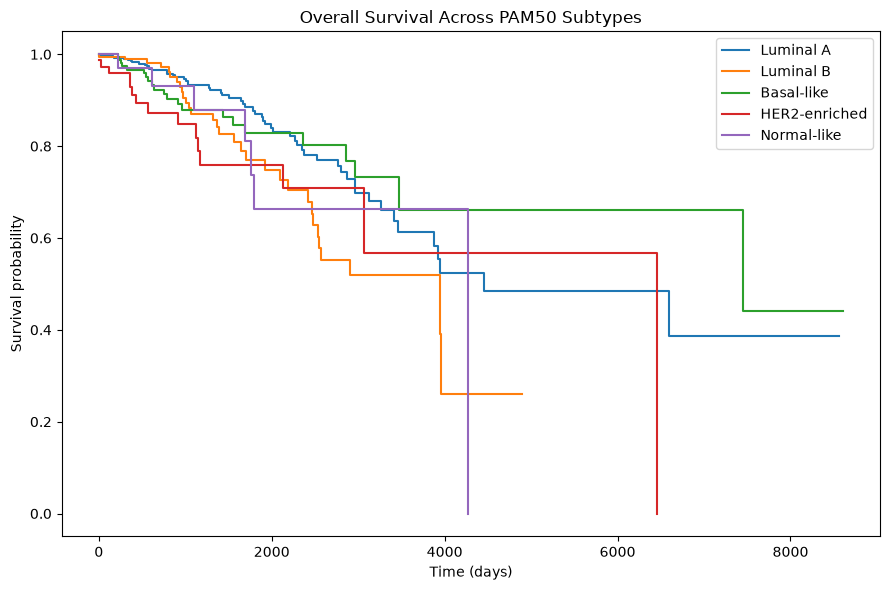

In [32]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(9, 6))

for subtype in subtype_order:
    subset = survival_subtype_df[
        survival_subtype_df["pam50_subtype"] == subtype
    ]

    kmf.fit(
        durations=subset["overall_survival_days"],
        event_observed=subset["overall_survival_event"],
        label=subtype
    )

    kmf.plot_survival_function(ci_show=False)

plt.title("Overall Survival Across PAM50 Subtypes")
plt.xlabel("Time (days)")
plt.ylabel("Survival probability")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "overall_survival_by_pam50_subtype.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
from lifelines.statistics import multivariate_logrank_test

logrank_result = multivariate_logrank_test(
    survival_subtype_df["overall_survival_days"],
    survival_subtype_df["pam50_subtype"],
    survival_subtype_df["overall_survival_event"]
)

print("=== Global Log-rank Test: PAM50 Subtypes ===")
print(f"Chi-square statistic: {logrank_result.test_statistic:.3f}")
print(f"p-value: {logrank_result.p_value:.6g}")

=== Global Log-rank Test: PAM50 Subtypes ===
Chi-square statistic: 10.650
p-value: 0.0307955


In [34]:
from itertools import combinations
from lifelines.statistics import logrank_test

pairwise_survival_results = []

for subtype1, subtype2 in combinations(subtype_order, 2):

    group1 = survival_subtype_df[
        survival_subtype_df["pam50_subtype"] == subtype1
    ]

    group2 = survival_subtype_df[
        survival_subtype_df["pam50_subtype"] == subtype2
    ]

    result = logrank_test(
        group1["overall_survival_days"],
        group2["overall_survival_days"],
        event_observed_A=group1["overall_survival_event"],
        event_observed_B=group2["overall_survival_event"]
    )

    pairwise_survival_results.append({
        "subtype_1": subtype1,
        "subtype_2": subtype2,
        "chi_square": result.test_statistic,
        "p_value": result.p_value
    })

survival_pairwise_df = pd.DataFrame(pairwise_survival_results)

# Bonferroni correction for 10 pairwise tests
n_tests = len(survival_pairwise_df)

survival_pairwise_df["p_adjusted"] = (
    survival_pairwise_df["p_value"] * n_tests
).clip(upper=1)

survival_pairwise_df["significant"] = (
    survival_pairwise_df["p_adjusted"] < 0.05
)

display(
    survival_pairwise_df
    .sort_values("p_adjusted")
    .round({
        "chi_square": 3,
        "p_value": 6,
        "p_adjusted": 6
    })
)

,subtype_1,subtype_2,chi_square,p_value,p_adjusted,significant
2,Luminal A,HER2-enriched,6.581,0.010305,0.103048,False
0,Luminal A,Luminal B,5.475,0.019295,0.192946,False
7,Basal-like,HER2-enriched,3.443,0.063520,0.635198,False
1,Luminal A,Basal-like,0.040,0.840666,1.000000,False
3,Luminal A,Normal-like,1.553,0.212760,1.000000,False
4,Luminal B,Basal-like,2.295,0.129825,1.000000,False
5,Luminal B,HER2-enriched,0.223,0.636822,1.000000,False
6,Luminal B,Normal-like,0.076,0.782656,1.000000,False
8,Basal-like,Normal-like,0.897,0.343683,1.000000,False
9,HER2-enriched,Normal-like,0.104,0.746672,1.000000,False


## 6. Save Results and Final Quality Control

In [35]:
# Save integrated clinical + PAM50 dataset

clinical_subtype_df.to_csv(
    PROCESSED_DIR / "tcga_brca_clinical_pam50.csv",
    index=False
)

# Save age pairwise comparisons
age_pairwise_df.to_csv(
    RESULTS_DIR / "05_age_pairwise_pam50.csv",
    index=False
)

# Save PAM50 survival pairwise comparisons
survival_pairwise_df.to_csv(
    RESULTS_DIR / "05_survival_pairwise_pam50.csv",
    index=False
)

# Save stage contingency table
stage_subtype_table.to_csv(
    RESULTS_DIR / "05_pam50_stage_contingency.csv"
)

print("05 results saved successfully.")

05 results saved successfully.


In [36]:
print("=== FINAL MOLECULAR SUBTYPE ANALYSIS QC ===")

print("Total clinical patients:", len(clinical_subtype_df))

print(
    "Patients with PAM50 subtype:",
    clinical_subtype_df["pam50_subtype"].notna().sum()
)

print(
    "PAM50 annotation coverage:",
    f"{clinical_subtype_df['pam50_subtype'].notna().mean() * 100:.1f}%"
)

print("\nPAM50 subtype distribution:")
print(
    clinical_subtype_df["pam50_subtype"]
    .value_counts()
    .reindex(subtype_order)
)

print("\nAge analysis:")
print(f"Kruskal-Wallis H = {kruskal_stat:.3f}")
print(f"p = {kruskal_p:.6g}")

print("\nStage analysis:")
print(f"Original chi-square = {chi2:.3f}")
print(f"p = {p:.6g}")
print(f"Sensitivity chi-square = {chi2_binary:.3f}")
print(f"Sensitivity p = {p_binary:.6g}")

print("\nSurvival analysis:")
print("Patients usable:", len(survival_subtype_df))
print(f"Global log-rank chi-square = {logrank_result.test_statistic:.3f}")
print(f"Global log-rank p = {logrank_result.p_value:.6g}")

print(
    "\nSignificant pairwise survival comparisons after Bonferroni:",
    survival_pairwise_df["significant"].sum()
)

=== FINAL MOLECULAR SUBTYPE ANALYSIS QC ===
Total clinical patients: 1098
Patients with PAM50 subtype: 981
PAM50 annotation coverage: 89.3%

PAM50 subtype distribution:
pam50_subtype
Luminal A        499
Luminal B        197
Basal-like       171
HER2-enriched     78
Normal-like       36
Name: count, dtype: int64

Age analysis:
Kruskal-Wallis H = 15.249
p = 0.00421136

Stage analysis:
Original chi-square = 37.991
p = 0.000154057
Sensitivity chi-square = 17.742
Sensitivity p = 0.00138586

Survival analysis:
Patients usable: 979
Global log-rank chi-square = 10.650
Global log-rank p = 0.0307955

Significant pairwise survival comparisons after Bonferroni: 0
